# Model Interpretability Write-up

NHS Clinical Audience - Plain English Explaination

Mental Health Risk Prediction Dataset

# 1. Purpose of the Model
  This data science model was created to help identify people who may be at increased risk of
  anxiety or depression using lifestyle, wellbeing, and stress-related information.

  The model is designed to support healthcare professionals by highlighting patterns linked
  with poor mental health outcomes.

  It is important to note that:

  --> The model does not diagnose mental illness
  --> The model does not replace clinicians
  --> The model only provides supportive risk information

  The final clinical decision must always remain with healthcare professionals.

    

# 2. Information Used by the Model
  The attached dataset contains information related to mental wellbeing.

  Examples include:

  Information Used

      Age
      Gender
      Sleep Hours
      Stress levels
      Physical activity
      Social support
      Lonliness score
      Anxiety score
      Depression score
      Financial stress
      Work stress
      Self-esteem
      Life satisfaction

      The model studies relationships between these factors and mental health outcomes.
      

# 3. How the Model Works (Plain English)
 The system learns patterns from previous records.

 For example, the model may observe that people with:

  high stress, poor sleep, loneliness, low social support

  often report higher anxiety or depression levels.

 When a new patient record is entered, the  model compares that information with patterns
 learned from earlier data.

 The model then estimates whether the person may have:

 lower risk, moderate risk, higher risk
 of mental health difficulties.

# 4. Main Factors Affecting Predictions 

# Sleep
Poor sleep is commonly linked with:
  Emotional distress, anxiety, low mood

Patients sleeping fewer hours may receive higher risk scores.

# Stress Levels
High stress is one of the strongest indicators in the dataset.

This includes:

 work stress, financial stress, personal pressure
 
 Higher stress levels may increase predicted mental health risk.

 # Social Support
 People with stronger support network  often show:

   better wellbeing, 
   lower loneliness, 
   reduced emotional distress.

 Lower social support may increase risk predictions.

 # Loneliness
 Loneliness is strongly linked with:
  depression, 
  emotional isolation, 
  anxiety symptoms.

The model treats loneliness as an important  warning sign.

# Physical Activity
Lower activity levels may relate to:
 reduced wellbeing, 
 higher stress, 
 poorer mood.

Regular activity may reduce predicted risk.

   

# 5. Clinical Meaning of Results
The model output should be interpreted as a risk indicator only.

MOdel Result                              Possible Meaning
Low Risk                                  Few warning signs detected
Moderate Risk                             Some mental health concerns identified
High Risk                                 Multiple risk factors detected

A higher score  does not confirm a diagnosis.
Instead, it suggests that additional review or support may be helpful.

# 6. Example Patient Interpretation 

# Example
A patient record shows:
 poor sleep, 
 high stress,
 high loneliness, 
 low social support.

The model may classify this patient as higher risk.

    For clinicians, this could suggest:
         further mental health discussion, 
         monitoring over time, 
         additional screening,
         referral consideration if appropriate.

        

# 7. Why Interpretability is important
Healthcare professionals must understand:
   why the model produced a result, 
   which factors influenced the prediction, 
   whether the result makes clinical sense. 
This improves:

 transparency,
 trust, 
 patient safety.

Interpretability helps avoid "black box" decision-making
 

# 8. Important Safety Considerations

The Model is not a diagnosis tool
The system cannot replace:
  clinical judgement,
  patient interviews, 
  safeguarding assessments, 
  crisis evaluation. 

# Data Quality Affects Reliability
Predictions depend on accurate information.

Missing or incorrect data may reduce reliability.

# Human Oversight is essential
    Clinicians should always:
      review the full patient situation,
      assess immediate risks directly, 
      use professional judgement before action. 
      

In [1]:
pip install numpy==1.26.4

Note: you may need to restart the kernel to use updated packages.Collecting numpy==1.26.4
  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6



ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.2.0 requires joblib~=1.1.0, but you have joblib 1.5.1 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
ydata-profiling 4.16.1 requires numba<=0.61,>=0.56.0, but you have numba 0.61.2 which is incompatible.
ydata-profiling 4.16.1 requires visions[type_image_path]<0.8.2,>=0.7.5, but you have visions 0.7.4 which is incompatible.


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

import shap

In [5]:
df = pd.read_csv('anxiety_depression_data.csv')

In [7]:
df.head()

,Age,Gender,Education_Level,Employment_Status,Sleep_Hours,Physical_Activity_Hrs,Social_Support_Score,Anxiety_Score,Depression_Score,Stress_Level,...,Chronic_Illnesses,Medication_Use,Therapy,Meditation,Substance_Use,Financial_Stress,Work_Stress,Self_Esteem_Score,Life_Satisfaction_Score,Loneliness_Score
0,56,Male,Bachelor's,Unemployed,6.0,0.4,3,4,2,9,...,0,NaN,0,1,NaN,4,3,7,5,1
1,69,Female,Bachelor's,Retired,8.8,2.8,6,18,7,6,...,0,NaN,1,0,NaN,1,4,7,4,6
2,46,Female,Master's,Employed,5.3,1.6,5,5,13,8,...,0,NaN,0,1,NaN,8,7,8,1,1
3,32,Female,High School,Unemployed,8.8,0.5,4,6,3,4,...,1,NaN,0,0,NaN,7,4,8,4,4
4,60,Female,Bachelor's,Retired,7.2,0.7,2,7,15,3,...,0,NaN,1,1,Frequent,8,9,5,7,7


In [9]:
df = df.dropna()

In [11]:
x = df[[
    'Sleep_Hours',
    'Stress_Level',
    'Social_Support_Score',
    'Loneliness_Score'
 ]]

y = df['Depression_Score']
    

In [13]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

In [15]:
model = RandomForestClassifier()

model.fit(x_train, y_train)

RandomForestClassifier()

In [17]:
predictions = model.predict(x_test)

In [19]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         0
           4       0.50      0.50      0.50         2
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         3
          12       0.00      0.00      0.00         1
          13       1.00      0.20      0.33         5
          15       0.00      0.00      0.00         1
          16       0.00      0.00      0.00         1
          18       0.00      0.00      0.00         2
          19       0.00      0.00      0.00         2
          20       0.00    

C:\Users\sahaj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sahaj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sahaj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sahaj\anaconda3\Lib\site-packages\sklea

In [21]:
importance = model.feature_importances_

feature_names = x.columns

for name, score in zip(feature_names, importance):
    print(name, score)

Sleep_Hours 0.34349643233086535
Stress_Level 0.22561706888092598
Social_Support_Score 0.22117011975720996
Loneliness_Score 0.2097163790309988


In [23]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         0
           4       0.50      0.50      0.50         2
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         3
          12       0.00      0.00      0.00         1
          13       1.00      0.20      0.33         5
          15       0.00      0.00      0.00         1
          16       0.00      0.00      0.00         1
          18       0.00      0.00      0.00         2
          19       0.00      0.00      0.00         2
          20       0.00    

C:\Users\sahaj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sahaj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sahaj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sahaj\anaconda3\Lib\site-packages\sklea

# Advanced Interpretability

In [25]:
pip install shap


  Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
pandas-profiling 3.2.0 requires joblib~=1.1.0, but you have joblib 1.5.1 which is incompatible.
ydata-profiling 4.16.1 requires numba<=0.61,>=0.56.0, but you have numba 0.61.2 which is incompatible.
ydata-profiling 4.16.1 requires numpy<2.2,>=1.16.0, but you have numpy 2.2.6 which is incompatible.
ydata-profiling 4.16.1 requires visions[type_image_path]<0.8.2,>=0.7.5, but you have visions 0.7.4 which is incompatible.


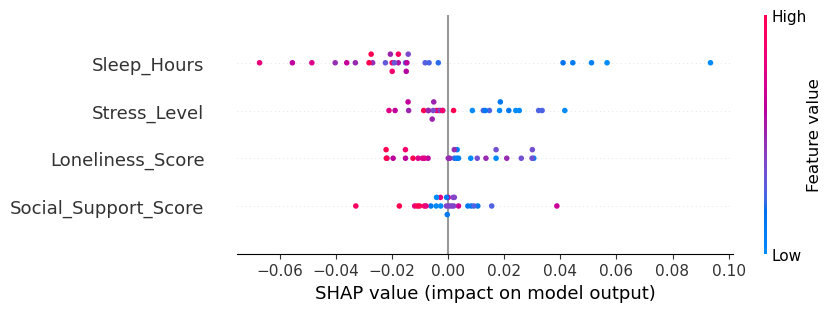

In [27]:
import shap

# Create explainer
explainer = shap.Explainer(model)

# Generate SHAP values
shap_values = explainer(x_test)

# Plot class 1 explanations
shap.plots.beeswarm(shap_values[:, :, 1])